In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from opacus import PrivacyEngine
import optuna
import sys
from functools import partial
import random
import numpy as np
import time
import os
import pickle
from scipy.stats import skewnorm
import os

# Experiment parameters

In [5]:
def seed_everything(seed):
    # Set random seed for reproducibility
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [6]:
os.makedirs('./toy-model-data', exist_ok=True)
os.makedirs('./temp', exist_ok=True)

seed = 42

seed_everything(seed)

# Parameters
D = 10  # Dimensionality
N = 1250  # Number of data points
EPOCHS = 10
LEARNING_RATE = 1e-1
BATCH_SIZE = 32
MAX_GRAD_NORMS = np.geomspace(1e-4, 30, 15)

# Data generation

In [7]:
def generate_skew_normal_data(n, d, skewness=4):
    # Generate skew-normal distributed data
    alpha = skewness * np.ones(d)  # Same skewness for each dimension
    data = skewnorm.rvs(a=alpha, loc=0, scale=1, size=(n, d))
    
    # Make it centered by subtracting the mean
    data -= np.mean(data, axis=0)
    
    return torch.tensor(data, dtype=torch.float32)

In [8]:
def generate_mixture_data_old(n, d, weight=0.9, mean1=0, mean2=5, cov1=1, cov2=0.5):
    n1 = int(n * weight)
    n2 = n - n1
    
    # Generate samples from Component 1
    data1 = torch.normal(mean=mean1, std=cov1, size=(n1, d))
    
    # Generate samples from Component 2
    data2 = torch.normal(mean=mean2, std=cov2, size=(n2, d))
    
    # Concatenate the data
    data = torch.cat([data1, data2], dim=0)
    
    # Shuffle the data to ensure random order
    indices = torch.randperm(n)
    data = data[indices]
    
    return data

In [23]:
def generate_mixture_data(n, d, mixture_dim=0, weight=0.9, mean1=0, mean2=5, cov1=1, cov2=0.5):
    """
    Generate a dataset where one dimension follows a mixture of two Gaussians,
    and the remaining dimensions follow standard Gaussian distributions.
    """
    # Generate standard Gaussian data for all dimensions
    data = torch.normal(mean=0, std=1, size=(n, d))
    
    # Generate the mixture component for the specified dimension
    n1 = int(n * weight)
    n2 = n - n1
    
    # Samples for the mixture dimension
    mixture_data1 = torch.normal(mean=mean1, std=cov1, size=(n1,))
    mixture_data2 = torch.normal(mean=mean2, std=cov2, size=(n2,))
    
    # Concatenate and shuffle the mixture data
    mixture_data = torch.cat([mixture_data1, mixture_data2], dim=0)
    mixture_data = mixture_data[torch.randperm(mixture_data.size(0))]
    
    # Replace the specified dimension with the mixture data
    data[:, mixture_dim] = mixture_data
    
    return data

In [24]:
# Generate synthetic data
#mean = torch.zeros(D)  # Zero mean
#cov = torch.eye(D)  # Standard Gaussian
#data = torch.distributions.MultivariateNormal(mean, cov).sample((n,))
#target = mean.repeat(N, 1)  # Our target is the true mean repeated

#data = generate_skew_normal_data(N, D, skewness=4)
#target = torch.zeros_like(data)

mixture_dim = 0
data = generate_mixture_data(N, D, mixture_dim=mixture_dim, mean2=10)
target = torch.zeros_like(data)

# Create DataLoader
dataset = TensorDataset(data, target)

# Split the dataset into training and validation
train_size = int(0.8 * N)  # 80% for training
val_size = N - train_size  # 20% for validation

TRAIN_DATASET, VAL_DATASET = random_split(dataset, [train_size, val_size])
print(f'Training dataset size: {len(TRAIN_DATASET)}')
print(f'Validation dataset size: {len(VAL_DATASET)}')

# Create DataLoaders
TRAIN_LOADER = DataLoader(TRAIN_DATASET, batch_size=BATCH_SIZE, shuffle=True)
VAL_LOADER = DataLoader(VAL_DATASET, batch_size=BATCH_SIZE, shuffle=False)

Training dataset size: 1000
Validation dataset size: 250


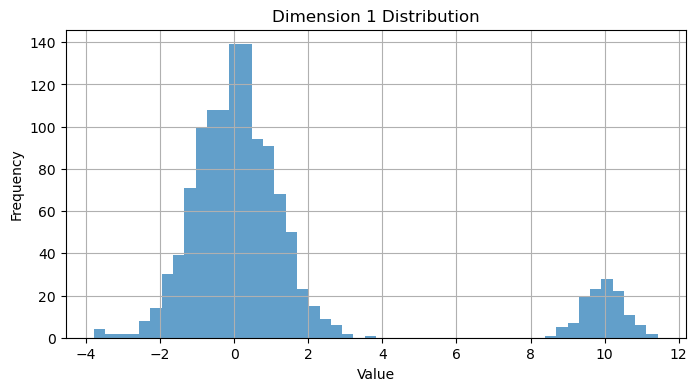

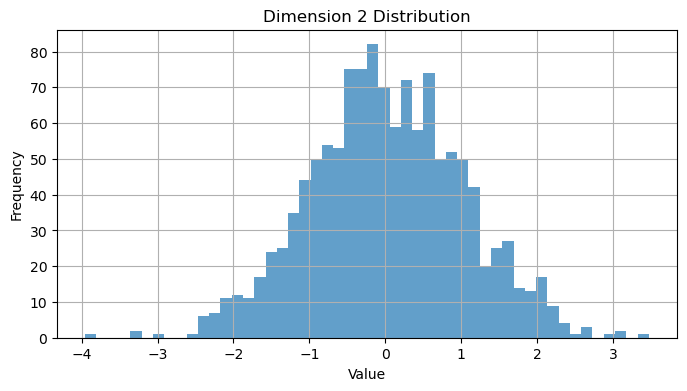

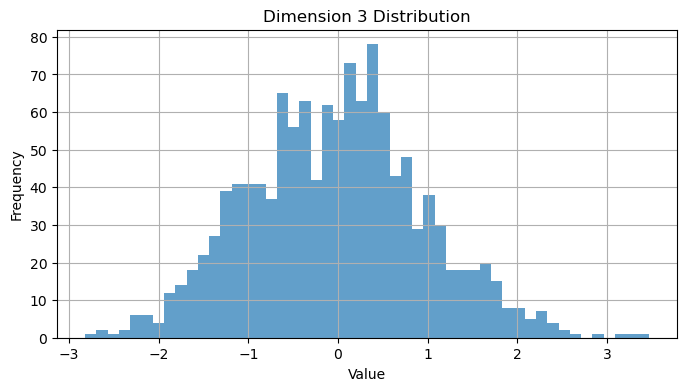

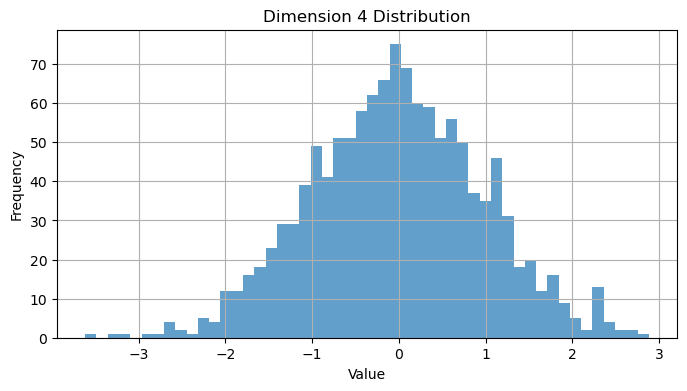

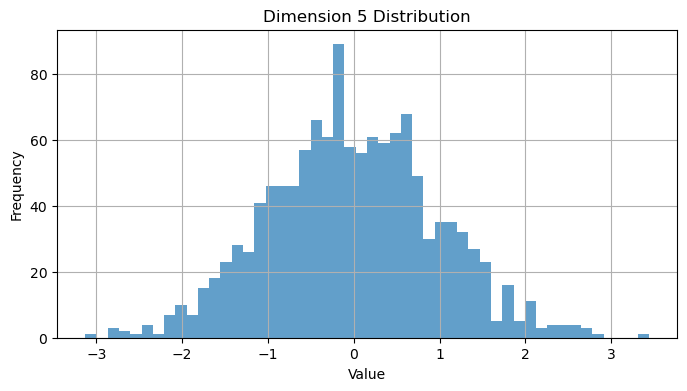

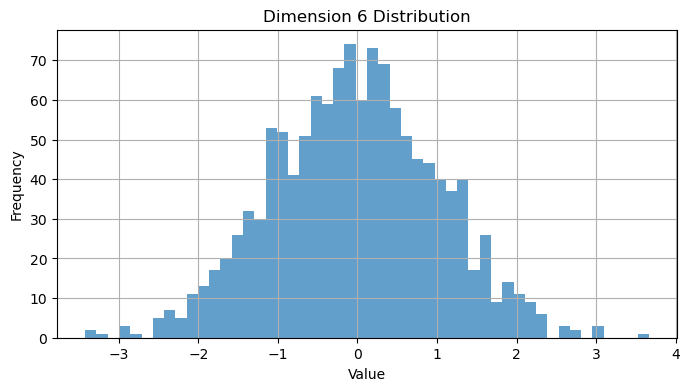

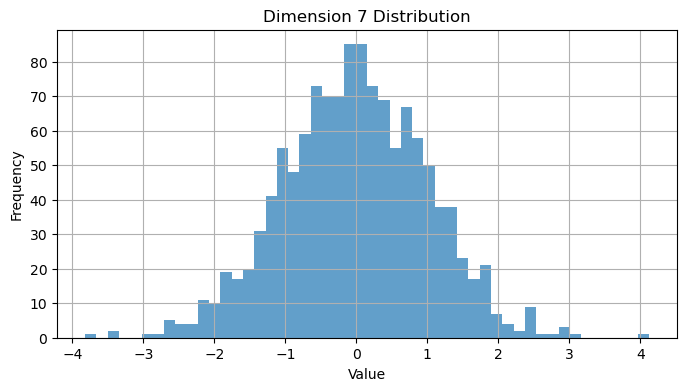

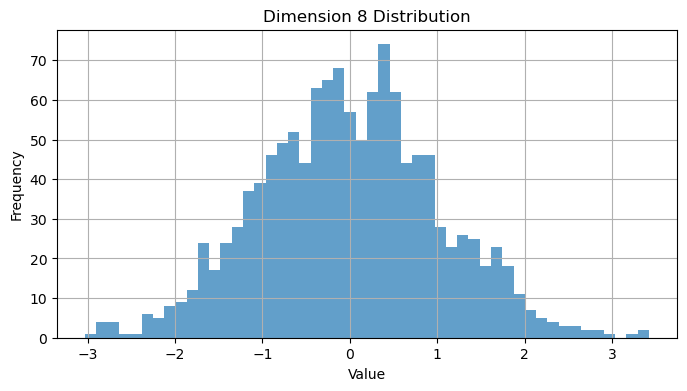

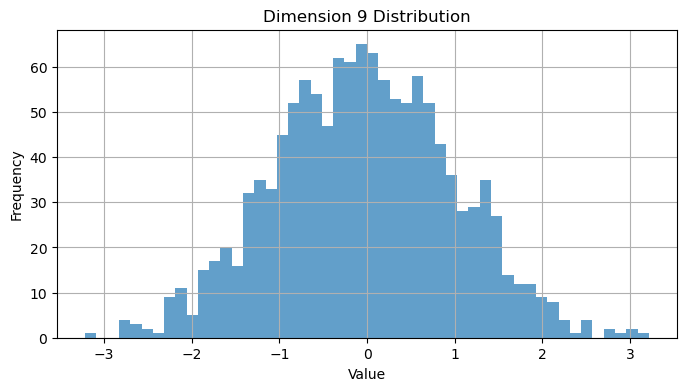

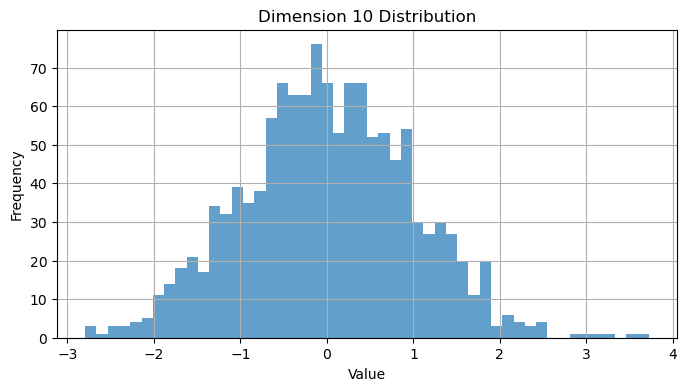

In [25]:
# Plot histograms for each dimension
for i in range(D):
    plt.figure(figsize=(8, 4))
    plt.hist(data[:, i].numpy(), bins=50, alpha=0.7)
    plt.title(f'Dimension {i+1} Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# Model

In [26]:
# Define a simple linear model
class LinearModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, input_dim, bias=False)

        # Initialize weights to 1
        torch.nn.init.constant_(self.fc.weight, 1.0)

    def forward(self, x):
        return self.fc(x)

In [27]:
def train_dp_model(train_loader, val_loader, epochs, learning_rate, max_grad_norm, epsilon):
    # Initialize model and optimizer
    model = LinearModel(D)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Wrap stuff inside Opacus
    privacy_engine = PrivacyEngine()
    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        target_epsilon=epsilon,
        target_delta=1e-5,
        max_grad_norm=max_grad_norm,
        epochs=epochs,
        normalize_clipping=True,
    )

    criterion = nn.MSELoss()
    train_losses = []
    val_losses = []
    clipped_proportions = []

    # Train and valid loop
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0

        for batch_data, batch_target in train_loader:
            optimizer.zero_grad()
            output = model(batch_data)
            loss = criterion(output, batch_target)
            loss.backward()

            # Calculate the proportion of clipped gradients
            total_gradients = 0
            clipped_gradients = 0
            for param in model.parameters():
                if param.grad_sample is not None:
                    total_gradients += param.grad_sample.numel()
                    clipped_gradients += (param.grad_sample.abs() > max_grad_norm).sum().item()

            clipped_proportion = clipped_gradients / total_gradients if total_gradients > 0 else 0
            clipped_proportions.append(clipped_proportion)

            optimizer.step()
            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for val_data, val_target in val_loader:
                val_output = model(val_data)
                val_loss = criterion(val_output, val_target)
                epoch_val_loss += val_loss.item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

    return train_losses[-1], val_losses[-1], clipped_proportions

# Experiment 1

In [28]:
def plot_results(max_grad_norms, results, epsilon):
    plt.figure(figsize=(10, 6))
    plt.plot(max_grad_norms, results, label=f"Epsilon = {epsilon}", marker='o')
    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')

    min_mse = min(results)
    plt.title(f'Effect of Maximum Gradient Norm on Toy model (epsilon={epsilon}) (Min MSE: {min_mse:.04})')
    plt.legend()
    plt.savefig(f'temp/toy-model-epsilon-{epsilon}.png')
    plt.grid(True)
    plt.show()

In [29]:
def plot_results_combined(max_grad_norms, train_results_dict, val_results_dict):
    plt.figure(figsize=(12, 8))
    
    # Consistent colors for epsilons
    colors = plt.cm.viridis(np.linspace(0, 1, len(train_results_dict)))

    for i, (epsilon, train_losses) in enumerate(train_results_dict.items()):
        val_losses = val_results_dict[epsilon]

        # Plot training losses with dotted lines
        plt.plot(max_grad_norms, train_losses, linestyle='--', color=colors[i], marker='o', label=f"Training Loss (ε = {epsilon})")
        
        # Plot validation losses with solid lines
        plt.plot(max_grad_norms, val_losses, linestyle='-', color=colors[i], marker='x', label=f"Validation Loss (ε = {epsilon})")

    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')
    plt.title('Effect of Maximum Gradient Norm on Toy Model')
    plt.legend()
    plt.grid(True)
    #plt.ylim([0,5])
    plt.savefig(f'temp/toy-model-all-epsilons.png')
    plt.show()


In [42]:
def plot_clipped_proportions_per_iteration(max_grad_norms, clipped_proportions_dict):

    colors = plt.cm.viridis(np.linspace(0, 1, len(max_grad_norms)))

    for epsilon in clipped_proportions_dict.keys():
        plt.figure(figsize=(10, 6))
        
        for idx, mgn in enumerate(max_grad_norms):
            # Get the clipped proportions for the current epsilon and max_grad_norm
            clipped_proportions = clipped_proportions_dict[epsilon][idx]

            # Plot them
            plt.plot(clipped_proportions, color=colors[idx], label=f'MGN = {mgn:.4f}')

        plt.xlabel('Iteration')
        plt.ylabel('Proportion of Clipped Gradients')
        plt.title(f'Proportion of clipped gradients vs. Iteration (Epsilon = {epsilon})')
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1,1))
        plt.savefig(f'temp/proportion-of-clipped-gradients-epsilon{epsilon}.png')
        plt.show()

In [31]:
def plot_last_clipped_proportion_vs_mgn(max_grad_norms, clipped_proportions_dict):
    plt.figure(figsize=(10, 6))

    colors = plt.cm.viridis(np.linspace(0, 1, len(clipped_proportions.keys())))

    for i, (epsilon, proportions_list) in enumerate(clipped_proportions_dict.items()):
        # Extract the proportion of clipped gradients for the last iteration
        last_clipped_proportions = [proportions[-1] for proportions in proportions_list]

        # Plot the last clipped proportions as a function of max_grad_norm
        plt.plot(max_grad_norms, last_clipped_proportions, color=colors[i], marker='o', label=f'Epsilon = {epsilon}')

    plt.xscale('log')
    plt.xlabel('Max Gradient Norm (Log Scale)')
    plt.ylabel('Proportion of clipped gradients (Last Iteration)')
    plt.title('Proportion of clipped Gradients vs. Max Gradient Norm')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.savefig('temp/proportion-of-clipped-gradients-vs-mgn-last-iteration.png')
    plt.show()

In [32]:
def experiment1():
    epsilon_values = [0.25, 1, 4, 8, 16]
    
    # Store results for all epsilon values
    train_results_dict = {}
    val_results_dict = {}
    clipped_proportions_dict = {}

    for epsilon in epsilon_values:
        print(f'Running for epsilon: {epsilon}')

        seed_everything(seed)
        
        # Compute results for all max_grad_norms
        results = [
            train_dp_model(TRAIN_LOADER, VAL_LOADER, epochs=EPOCHS, learning_rate=LEARNING_RATE, max_grad_norm=mgn, epsilon=epsilon)
            for mgn in MAX_GRAD_NORMS
        ]
        
        # Unpack results into separate lists for train losses, val losses, and clipped proportions
        train_losses, val_losses, clipped_proportions = zip(*results)
        
        # Store the results in the dictionaries
        train_results_dict[epsilon] = train_losses
        val_results_dict[epsilon] = val_losses
        clipped_proportions_dict[epsilon] = clipped_proportions
    
    # Plot all results in a single plot
    plot_results_combined(MAX_GRAD_NORMS, train_results_dict, val_results_dict)

    return train_results_dict, val_results_dict, clipped_proportions_dict

Running for epsilon: 0.25


/home/arehn/git/opacus-decouple/opacus/privacy_engine.py:95: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/home/arehn/git/opacus-decouple/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/torch/nn/modules/module.py:1344: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


Running for epsilon: 1
Running for epsilon: 4
Running for epsilon: 8
Running for epsilon: 16


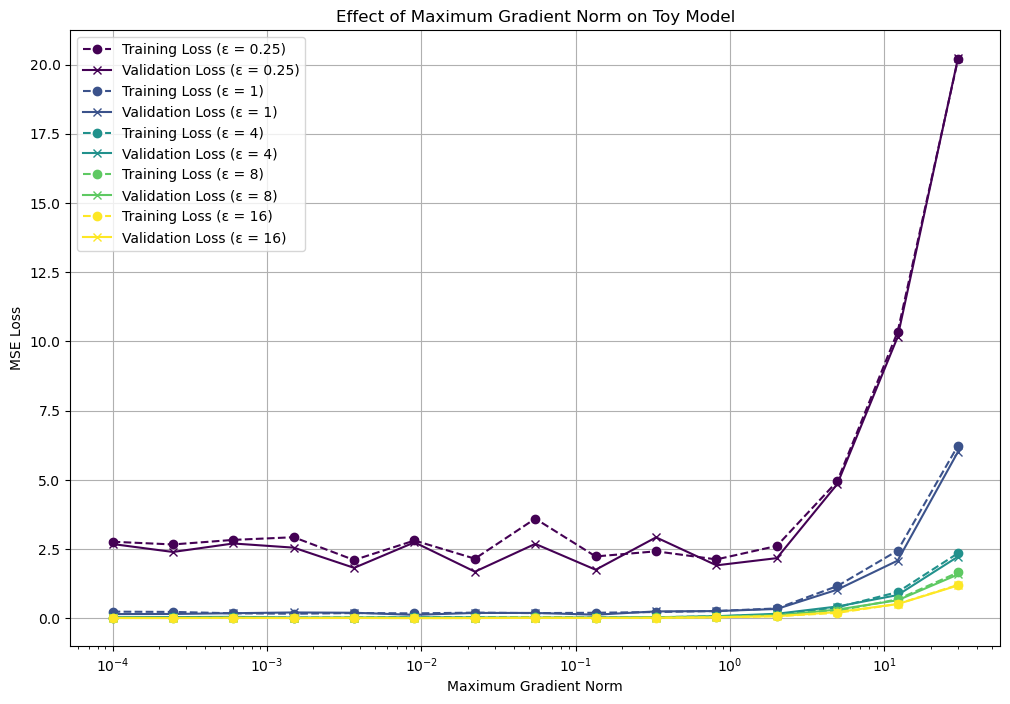

In [33]:
train_losses, val_losses, clipped_proportions = experiment1()

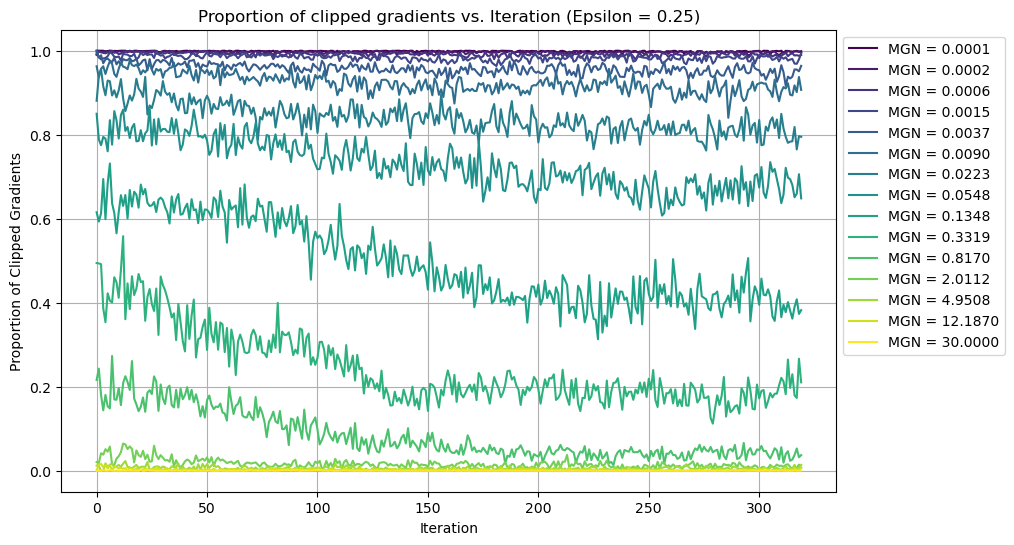

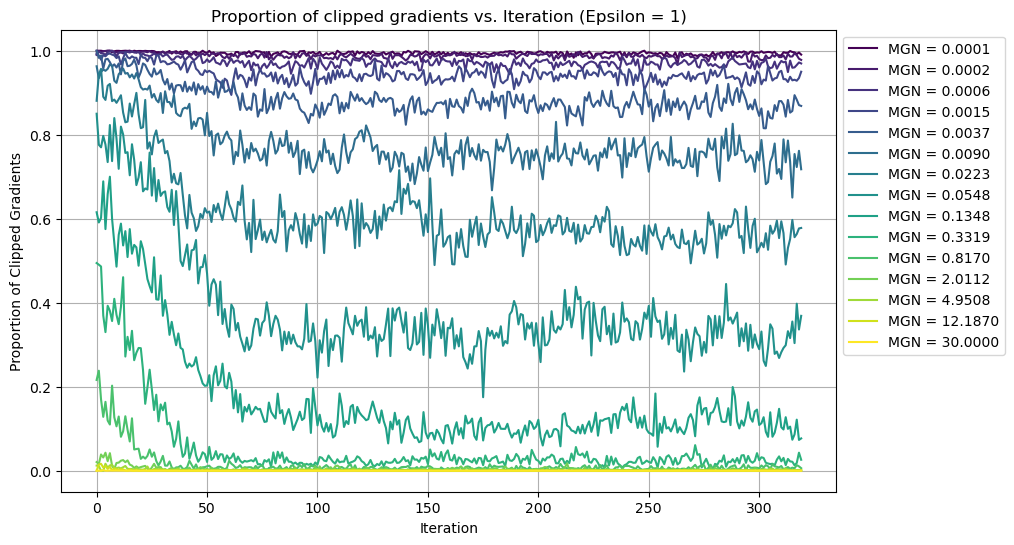

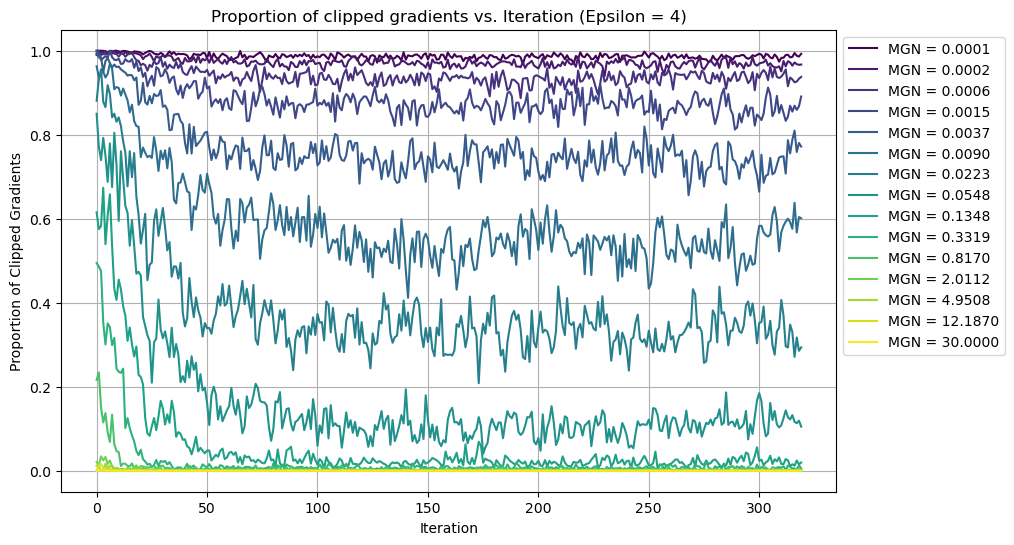

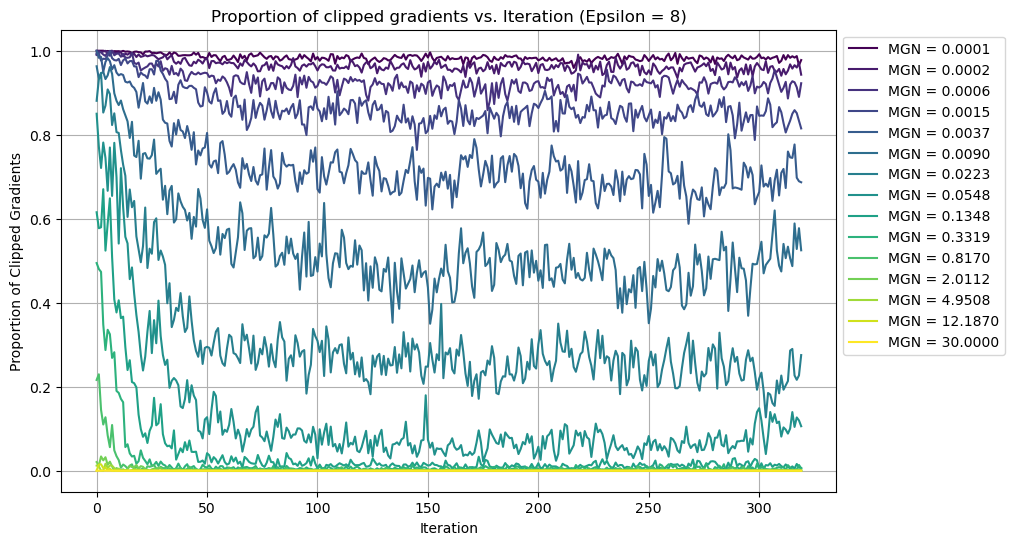

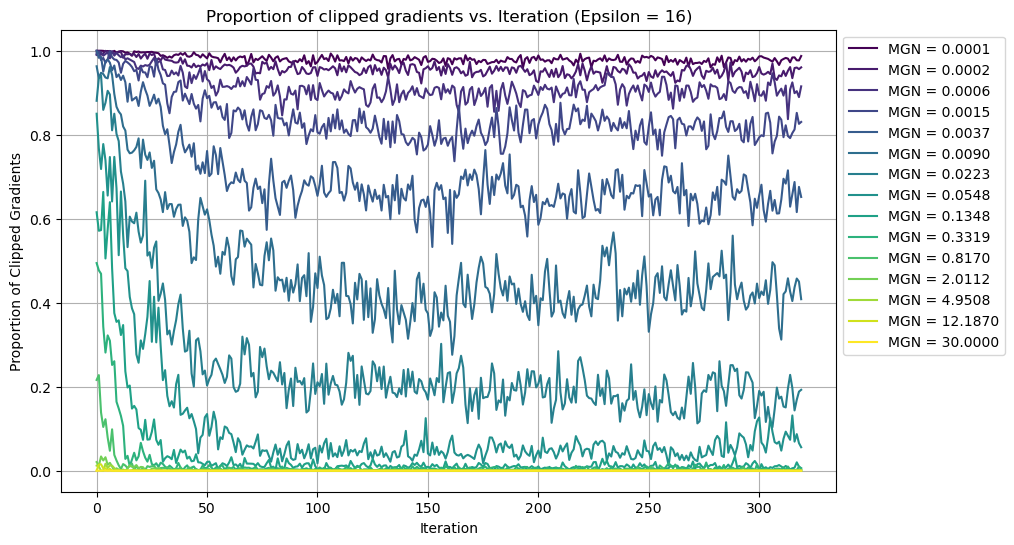

In [43]:
plot_clipped_proportions_per_iteration(MAX_GRAD_NORMS, clipped_proportions)

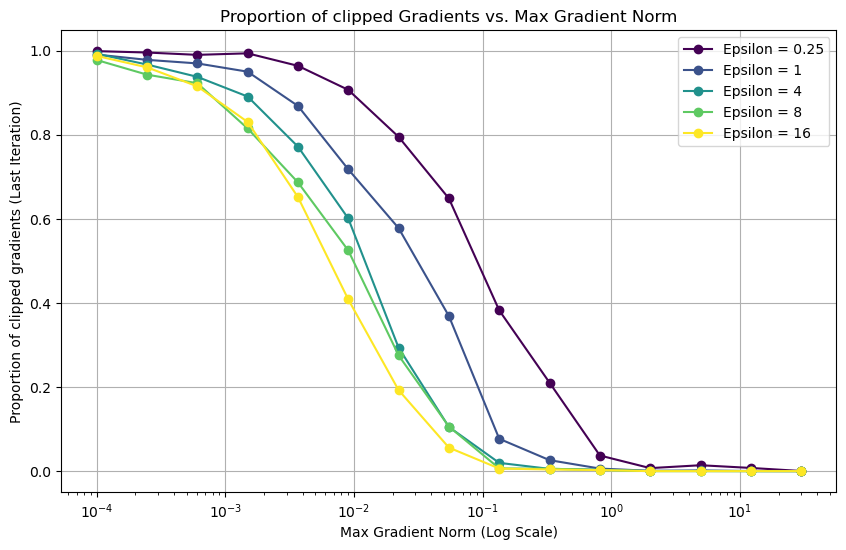

In [44]:
plot_last_clipped_proportion_vs_mgn(MAX_GRAD_NORMS, clipped_proportions)

# Experiment 2

In [ ]:
def plot_mean_with_confidence_intervals(max_grad_norms, all_results_dict, n_repeats, epsilon, save_fname=None):
    means = []
    conf_intervals = []

    # Calculate mean and confidence intervals for each max_grad_norm
    for mgn in max_grad_norms:
        losses = all_results_dict[mgn]
        mean_loss = np.mean(losses)
        std_dev = np.std(losses)
        conf_interval = 1.96 * (std_dev / np.sqrt(len(losses)))

        means.append(mean_loss)
        conf_intervals.append(conf_interval)

    # Plot mean line with confidence intervals
    plt.figure(figsize=(12, 8))
    plt.plot(max_grad_norms, means, color='b', marker='o', label='Mean MSE Loss')
    plt.fill_between(max_grad_norms, np.array(means) - np.array(conf_intervals), np.array(means) + np.array(conf_intervals), color='b', alpha=0.2, label='95% CI')
    
    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('Mean MSE Loss')
    plt.title(f'Mean MSE Loss with 95% Confidence Intervals ({n_repeats} repeats) (ε = {epsilon})')
    plt.legend()
    #plt.ylim([0,10])
    plt.grid(True)
    
    if save_fname:
        plt.savefig(save_fname)

    plt.show()


In [ ]:
def plot_all_repeats(max_grad_norms, all_results, n_repeats, epsilon, save_fname=None):
    plt.figure(figsize=(12, 8))

    # Iterate over each repeat
    for i, repeat_losses in enumerate(all_results):
        # Plot each repeat's results as a separate line
        plt.plot(max_grad_norms, repeat_losses, alpha=0.5, color='blue', linewidth=0.5)

    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')
    plt.title(f'All {n_repeats} Repeats for MSE Losses (ε = {epsilon})')
    plt.grid(True)
    #plt.ylim([0,10])
    
    if save_fname:
        plt.savefig(save_fname)

    plt.show()

In [ ]:
def experiment2():
    n_repeats = 100
    epsilon = 0.25
    all_results_dict = {mgn: [] for mgn in MAX_GRAD_NORMS}  # For confidence intervals
    all_results_list = []  # For plotting all the repeats separately
    
    for i in range(n_repeats):
        print(f'* Running repeat {i+1}..')
        repeat_losses = []
        seed_everything(seed+i)
        
        # Compute results for all max_grad_norms
        for mgn in MAX_GRAD_NORMS:
            train_loss, val_loss, _ = train_dp_model(
                TRAIN_LOADER,
                VAL_LOADER,
                epochs=EPOCHS,
                learning_rate=LEARNING_RATE,
                max_grad_norm=mgn,
                epsilon=epsilon,
            )
            all_results_dict[mgn].append(val_loss)
            repeat_losses.append(val_loss)
            
        all_results_list.append(repeat_losses)
    
    plot_all_repeats(
        MAX_GRAD_NORMS,
        all_results_list,
        n_repeats,
        epsilon,
        save_fname=f'temp/toy-model-epsilon-{epsilon}-{n_repeats}-repeats-raw-data.png',
    )

    plot_mean_with_confidence_intervals(
        MAX_GRAD_NORMS,
        all_results_dict,
        n_repeats,
        epsilon,
        save_fname=f'temp/toy-model-epsilon-{epsilon}-{n_repeats}-repeats-mean-with-confidence.png',
    )

    return all_results_dict, all_results_list

In [ ]:
#losses_dict, losses_list = experiment2()

In [ ]:
# n_repeats = 100
# epsilon = 0.25

# plot_mean_with_confidence_intervals(
#     MAX_GRAD_NORMS,
#     losses_dict,
#     n_repeats,
#     epsilon,
#     'temp/mixture-confidence-intervals.png',
# )

# Experiment 3

In [ ]:
def experiment3():
    epsilon = 0.25
    initial_repeats = 100
    final_repeats = 800
    # Store results here
    all_results_dict = {mgn: [] for mgn in MAX_GRAD_NORMS}  # For confidence intervals
    all_results_list = []  # For plotting all the repeats separately
    
    def run_experiments(n_repeats):        
        for i in range(n_repeats):
            print(f'* Running repeat {i+1}..')
            seed_everything(seed+i)

            repeat_losses = []
            for mgn in MAX_GRAD_NORMS:
                train_loss, val_loss, _ = train_dp_model(
                    TRAIN_LOADER,
                    VAL_LOADER,
                    epochs=EPOCHS,
                    learning_rate=LEARNING_RATE,
                    max_grad_norm=mgn,
                    epsilon=epsilon,
                )
                
                all_results_dict[mgn].append(val_loss)  # Collect validation losses
                repeat_losses.append(val_loss)
                
            all_results_list.append(repeat_losses)
    
    current_repeats = initial_repeats
    while current_repeats <= final_repeats:
        print(f'Running with {current_repeats} repeats...')
        run_experiments(current_repeats)
                
        plot_all_repeats(
            MAX_GRAD_NORMS,
            all_results_list,
            current_repeats,
            epsilon,
            f'temp/toy-model-epsilon-{epsilon}-{current_repeats}-repeats-raw-data.png',
        )
        plot_mean_with_confidence_intervals(
            MAX_GRAD_NORMS,
            all_results_dict,
            current_repeats,
            epsilon,
            save_fname=f'temp/toy-model-epsilon-{epsilon}-{current_repeats}-repeats-mean-with-confidence.png',
        )
    
        current_repeats *= 2

    return all_results_dict, all_results_list

In [ ]:
#losses_dict, losses_list = experiment3()

# Experiment 4

In [ ]:
def objective(trial: optuna.trial.Trial, max_grad_norm: float):
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1.0)
    batch_size = trial.suggest_int('batch_size', 8, 1000)
    epochs = EPOCHS
    epsilon = 0.25

    print(f'*** Running with max_grad_norm: {max_grad_norm}, learning_rate: {learning_rate}, batch_size: {batch_size}')

    # Create data loaders
    train_loader = DataLoader(TRAIN_DATASET, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(VAL_DATASET, batch_size=len(VAL_DATASET), shuffle=False)

    train_loss, val_loss, _ = train_dp_model(train_loader, val_loader, epochs, learning_rate, max_grad_norm, epsilon)
    print(f'****** Training Loss: {train_loss}, Validation Loss: {val_loss}')

    return val_loss  # We want to minimize validation loss

In [ ]:
def optimize(max_grad_norm, n_trials: int = 20, direction: str ='minimize', seed: int = 42):
    seed_everything(seed)

    sampler_cls = getattr(optuna.integration, 'BoTorchSampler')
    sampler = sampler_cls(seed=seed)

    study = optuna.create_study(
        storage='sqlite:///optuna-toy-model.db',
        study_name=f'dp_toy_model_optimization-mgn{max_grad_norm:.5f}',
        sampler=sampler,
        direction=direction,
    )

    objective_func = partial(objective, max_grad_norm=max_grad_norm)
    
    study.optimize(
        objective_func,
        n_trials=n_trials,
        gc_after_trial=True,  # garbage collect after each trial
    )

    trial = study.best_trial
    print(f'Best objective value: {trial.value}', file=sys.stderr)
    print('Best parameters:', file=sys.stderr)
    for key, value in trial.params.items():
        print(f' - {key}: {value}', file=sys.stderr)

    return trial.value, trial.params

In [ ]:
def plot_losses_vs_max_grad_norms(max_grad_norms, optimized_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(max_grad_norms, optimized_losses, marker='o', linestyle='-', color='b')
    plt.xscale('log')
    plt.xlabel('Max Gradient Norm')
    plt.ylabel('Loss')
    plt.title('Loss after HPO as a Function of Max Gradient Norm')
    plt.grid(True)
    #plt.ylim([0, 5])
    plt.savefig('temp/toy-model-epsilon-0.25-HPO.png')
    plt.show()


In [ ]:
def experiment4():
    optimized_losses = []
    optimized_params = []
    
    total_start_time = time.time()
    
    for max_grad_norm in MAX_GRAD_NORMS:
        print(f'Optimizing for max_grad_norm: {max_grad_norm}')
        
        study_start_time = time.time()
        best_loss, best_params = optimize(max_grad_norm, n_trials=150, seed=seed)
        study_duration = time.time() - study_start_time
        print(f'Study for max_grad_norm {max_grad_norm} took {study_duration:.2f} seconds')
        
        optimized_losses.append(best_loss)
        optimized_params.append(best_params)
    
    total_duration = time.time() - total_start_time
    print(f'Total runtime for all studies: {total_duration:.2f} seconds')

    with open('./toy-model-data/optimized_losses.pkl', 'wb') as f:
        pickle.dump(optimized_losses, f)
    
    # Save optimized_params
    with open('./toy-model-data/optimized_params.pkl', 'wb') as f:
        pickle.dump(optimized_params, f)
    
    plot_losses_vs_max_grad_norms(MAX_GRAD_NORMS, optimized_losses)

    return optimized_losses, optimized_params

In [ ]:
optimized_losses, optimized_params = experiment4()

# Experiment 5

In [ ]:
def experiment_with_optimized_hypers(max_grad_norms, optimized_params, n, d, epochs, epsilon):
    initial_repeats = 100
    final_repeats = 800
        
    # Store results here
    all_results_dict = {mgn: [] for mgn in max_grad_norms}  # For confidence intervals
    all_results_list = []  # For plotting all the repeats separately
    
    # Function to incrementally run experiments
    def run_experiments(n_repeats):
        for i in range(n_repeats):
            print(f'* Running repeat {i+1}..')
            seed_everything(seed+i)

            repeat_losses = []
            for idx, mgn in enumerate(max_grad_norms):
                # Get optimized hyperparameters for this max_grad_norm
                params = optimized_params[idx]
                learning_rate = params['learning_rate']
                batch_size = params['batch_size']

                # Create data loaders
                train_loader = DataLoader(TRAIN_DATASET, batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(VAL_DATASET, batch_size=len(VAL_DATASET), shuffle=False)

                # Train the model
                train_loss, val_loss, _ = train_dp_model(train_loader, val_loader, epochs, learning_rate, mgn, epsilon)
                
                all_results_dict[mgn].append(val_loss)  # Collect validation losses
                repeat_losses.append(val_loss)
                
            all_results_list.append(repeat_losses)
    
    # Main loop to double the repeats
    current_repeats = initial_repeats
    while current_repeats <= final_repeats:
        print(f'Running with {current_repeats} repeats...')
        run_experiments(current_repeats)
    
        # Plot the results after each iteration
        plot_all_repeats(
            max_grad_norms,
            all_results_list,
            current_repeats,
            epsilon,
            save_fname=f'temp/toy-model-HPO-epsilon-{epsilon}-{current_repeats}-repeats-raw-data.png',
        )
        plot_mean_with_confidence_intervals(
            max_grad_norms,
            all_results_dict,
            current_repeats,
            epsilon,
            save_fname=f'temp/toy-model-HPO-epsilon-{epsilon}-{current_repeats}-repeats-mean-with-confidence.png'
        )
    
        # Double the number of repeats for the next iteration
        current_repeats *= 2
    
    return all_results_list, all_results_dict

In [ ]:
with open('./toy-model-data/optimized_params.pkl', 'rb') as f:
    optimized_params = pickle.load(f)

with open('./toy-model-data/optimized_losses.pkl', 'rb') as f:
    optimized_losses = pickle.load(f)

In [ ]:
epsilon = 0.25

all_results_list, all_results_dict = experiment_with_optimized_hypers(
    MAX_GRAD_NORMS,
    optimized_params,
    N,
    D,
    EPOCHS,
    epsilon,
)

# Experiment 6

In [ ]:
def experiment6(optimized_params, epsilon=0.25):
    # Store results for all epsilon values
    train_results_dict = {}
    val_results_dict = {}
    clipped_proportions_dict = {}

    seed_everything(seed)

    results = []
    # Compute results for all max_grad_norms
    for i, mgn in enumerate(MAX_GRAD_NORMS):
        hypers = optimized_params[i]
        learning_rate = hypers['learning_rate']
        batch_size = hypers['batch_size']

        # Create data loaders
        train_loader = DataLoader(TRAIN_DATASET, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(VAL_DATASET, batch_size=len(VAL_DATASET), shuffle=False)

        result = train_dp_model(train_loader, val_loader, epochs=EPOCHS, learning_rate=learning_rate, max_grad_norm=mgn, epsilon=epsilon)
        results.append(result)
    
    # Unpack results into separate lists for train losses, val losses, and clipped proportions
    train_losses, val_losses, clipped_proportions = zip(*results)

    # Store the results in the dictionaries
    train_results_dict[epsilon] = train_losses
    val_results_dict[epsilon] = val_losses
    clipped_proportions_dict[epsilon] = clipped_proportions

    return train_results_dict, val_results_dict, clipped_proportions_dict

In [ ]:
train_losses, val_losses, clipped_proportions = experiment6(optimized_params, epsilon=0.25)

In [ ]:
plot_clipped_proportions_per_iteration(MAX_GRAD_NORMS, clipped_proportions)

In [ ]:
plot_last_clipped_proportion_vs_mgn(MAX_GRAD_NORMS, clipped_proportions)